# MIM electronics simulator — `mimsim`

A traveling-wave / S-parameter simulator for the **microwave impedance microscopy (MIM)**
signal chain, following Barber, Ma & Shen, *Nat. Rev. Phys.* **4**, 61 (2022), Fig. 1a.

**What it does**

- Models the full chain as a scattering network: source → directional coupler →
  matching network → tip-sample load → amplifier → IQ mixer.
- Solves the network at the carrier frequency using normalized scattering waves:
  `(I − S·P)·b = b_src`, so reflections, impedance mismatch and cancellation are
  all physical.
- Lets you **probe the signal at the input or output of any component**, in both the
  **time domain** (the RF waveform) and the **frequency domain** (carrier + sidebands).
- **Attenuator** and **phase shifter** are driven by a control **voltage** through a
  user-definable response curve; the **source amplitude and frequency** are tunable.

Every signal is stored as a complex baseband envelope on a slow-time grid, so slow
modulation (tip-height oscillation, drift, gate sweeps) and the GHz carrier are handled
on their two natural timescales.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mimsim import (
    Network, Source, DirectionalCoupler, MatchingNetwork, Amplifier,
    PhaseShifter, Attenuator, IQMixer, Termination, Load, Signal, DemodResult,
    series_L, series_C, shunt_C, shunt_L, tline, TipSampleModel, EPS0,
    resonant_match,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
f0 = 1e9  # 1 GHz carrier, as in the paper's Fig. 1b


## 1. Build the MIM chain — three arms

Following the paper's Fig. 1a, **one** microwave source is split into three arms (ports
carry named handles — `"in"`, `"through"`, `"coupled"`, `"isolated"`, `"rf"`, `"lo"` — so
the wiring reads like the block diagram):

- **Excitation** → directional coupler → matching network → tip.
- **Cancellation** → attenuator **A** + phase shifter **ϕ** → a second coupler (the
  *combiner*), where the synthesized wave **meets the reflected wave and nulls the carrier**
  before amplification. This is where `A`/`ϕ` live in a real instrument.
- **Reference** → phase shifter **ϕ** → the mixer LO, setting the I/Q demodulation phase.

The reflection from the tip returns through the excitation coupler's **isolated** port,
meets the cancellation wave at the combiner, then → amplifier → mixer RF port. The
cancellation attenuator defaults to "off" (high attenuation); Section 8 tunes it on.

In [2]:
def build_chain(f0, tip, coupling_db=10.0):
    """Faithful three-arm MIM reflectometer (paper Fig. 1a): one source split into
    Excitation / Cancellation / Reference arms."""
    src  = Source(f0, amplitude=1.0, name="src")
    cpl1 = DirectionalCoupler(coupling_db=3.0, directivity_db=35.0, name="cpl1")   # source split
    cpl2 = DirectionalCoupler(coupling_db=3.0, directivity_db=35.0, name="cpl2")   # ref / cancel split
    cplm = DirectionalCoupler(coupling_db=coupling_db, directivity_db=35.0, name="cplm")  # excitation/reflection
    comb = DirectionalCoupler(coupling_db=3.0, directivity_db=35.0, name="comb")   # cancellation combiner
    match = resonant_match(f0, C_probe=1e-12, Q=40.0, name="match")               # lambda/4 probe match
    ref_ph  = PhaseShifter(voltage=0.0, name="ref_ph")                            # reference arm: phi (LO phase)
    can_att = Attenuator(voltage=120.0, response=lambda v: v, name="can_att")     # cancellation arm: A (off by default)
    can_ph  = PhaseShifter(voltage=0.0, name="can_ph")                            # cancellation arm: phi
    amp = Amplifier(gain_db=30.0, name="amp")
    mix = IQMixer(name="mixer")

    net = Network(f0=f0)
    net.connect(src.port(0),        cpl1.port("in"))
    net.connect(cpl1.port("through"), cplm.port("in"))      # -> excitation
    net.connect(cpl1.port("coupled"), cpl2.port("in"))      # -> reference + cancellation tap
    # reference arm (phase shifter) -> LO
    net.connect(cpl2.port("through"), ref_ph.port("in"))
    net.connect(ref_ph.port("out"),  mix.port("lo"))
    # cancellation arm (attenuator + phase shifter) -> combiner
    net.connect(cpl2.port("coupled"), can_att.port("in"))
    net.connect(can_att.port("out"),  can_ph.port("in"))
    net.connect(can_ph.port("out"),   comb.port("isolated"))
    # excitation -> matching -> tip
    net.connect(cplm.port("through"), match.port("in"))
    net.connect(match.port("out"),    tip.port(0))
    # reflected wave meets the cancellation wave at the combiner, then -> amplifier -> RF
    net.connect(cplm.port("isolated"), comb.port("in"))
    net.connect(comb.port("through"),  amp.port("in"))
    net.connect(amp.port("out"),       mix.port("rf"))
    return net, dict(src=src, cpl1=cpl1, cpl2=cpl2, cplm=cplm, comb=comb, match=match,
                     ref_ph=ref_ph, can_att=can_att, can_ph=can_ph, amp=amp, mix=mix)

model = TipSampleModel()               # lumped tip-sample admittance model
tip = model.make_load(rho=1.0, eps_r=10.0, name="tip")   # rho = 1 Ohm*m sample
net, C = build_chain(f0, tip)
print("components:", [c.name for c in net.components])
print("connections:", len(net.connections))


components: ['src', 'cpl1', 'cplm', 'cpl2', 'ref_ph', 'mixer', 'can_att', 'can_ph', 'comb', 'match', 'tip', 'amp']
connections: 13


## 2. Probe any node — time domain and frequency domain

`net.run()` solves the network. From the result you can pull the signal at **any port**:

- `res.incident(port)` / `res.reflected(port)` — the forward / backward traveling wave
- `res.voltage(port)` / `res.current(port)` — total node voltage / current

Each is a `Signal`: `.waveform()` reconstructs the RF oscillation (time domain),
`.spectrum()` gives the RF spectrum (frequency domain).

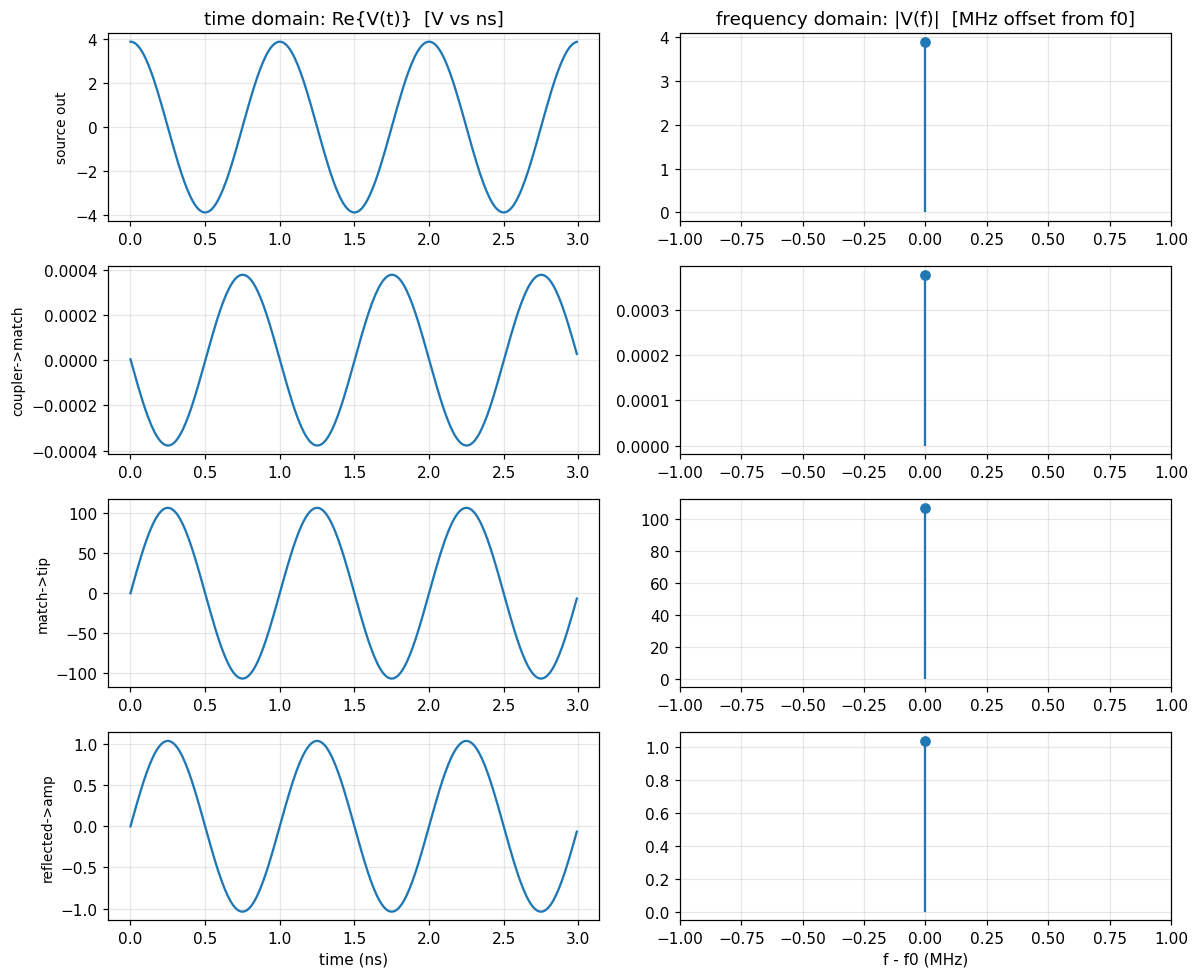

Voltage magnitude at match.out : 106.92024073116166
Reflection |Gamma| at tip      : 0.9999999945707099


In [3]:
res = net.run()   # static (CW) solve

# pick nodes at the input/output of several components
nodes = [
    ("source out",   C["src"].port(0)),
    ("coupler->match", C["match"].port("in")),
    ("match->tip",   C["match"].port("out")),
    ("reflected->amp", C["amp"].port("in")),
]

fig, axes = plt.subplots(len(nodes), 2, figsize=(11, 9))
for row, (label, port) in enumerate(nodes):
    v = res.voltage(port)
    t_fast, wave = v.waveform(n_periods=3, samples_per_period=100)
    axes[row, 0].plot(t_fast * 1e9, wave)
    axes[row, 0].set_ylabel(label, fontsize=9)
    freq, V = v.spectrum()
    axes[row, 1].stem((freq - f0) / 1e6 if freq.size > 1 else [0], np.abs(V))
    axes[row, 1].set_xlim(-1, 1)
axes[0, 0].set_title("time domain: Re{V(t)}  [V vs ns]")
axes[0, 1].set_title("frequency domain: |V(f)|  [MHz offset from f0]")
axes[-1, 0].set_xlabel("time (ns)")
axes[-1, 1].set_xlabel("f - f0 (MHz)")
plt.tight_layout(); plt.show()

# read a scalar off any node directly:
print("Voltage magnitude at match.out :", np.abs(res.voltage(C["match"].port("out")).env[0]))
print("Reflection |Gamma| at tip      :",
      np.abs(res.reflected(tip.port(0)).env[0] / res.incident(tip.port(0)).env[0]))


## 3. Voltage-controlled attenuator and phase shifter

Both components map an applied **voltage** through a response curve (default 1 dB/V and
1 rad/V; pass any callable for a real device). We exercise them in their real roles:
the **reference-arm phase shifter** sets the LO phase, and the **cancellation-arm
attenuator** sets how strongly the carrier is nulled at the amplifier input.

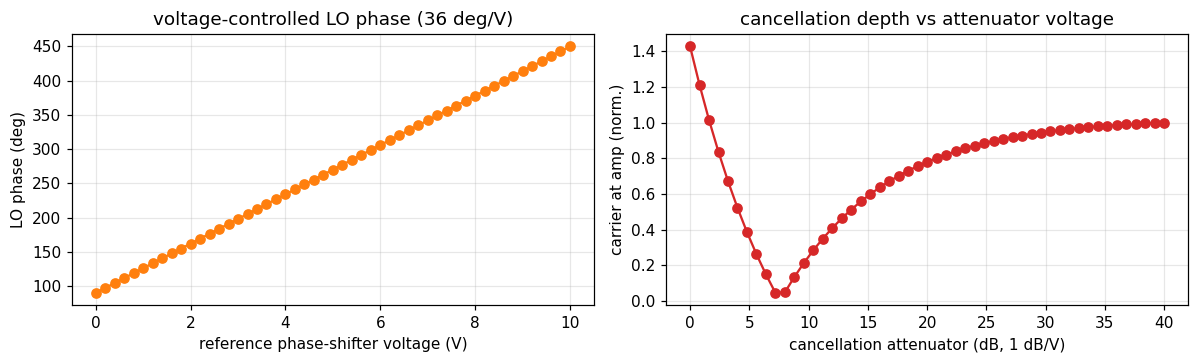

In [4]:
# reference-arm phase shifter: 36 deg/V  ->  LO phase
C["ref_ph"].response = lambda v: np.deg2rad(36.0 * v)
volts = np.linspace(0, 10, 51)
lo_phase = []
for v in volts:
    C["ref_ph"].voltage = v
    lo_phase.append(np.angle(net.run().incident(C["mix"].port("lo")).env[0]))
C["ref_ph"].voltage = 0.0

# cancellation-arm attenuator: sweep attenuation -> carrier level at amplifier input
C["can_ph"].voltage = np.pi          # phase set for cancellation (tuned properly in Sec 8)
atten_db = np.linspace(0, 40, 51)
carrier = []
for a in atten_db:
    C["can_att"].voltage = a         # default response: 1 dB per volt
    carrier.append(np.abs(net.run().incident(C["amp"].port("in")).env[0]))
C["can_att"].voltage = 120.0; C["can_ph"].voltage = 0.0     # reset (cancellation off)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(volts, np.rad2deg(np.unwrap(lo_phase)), "o-", color="C1")
ax[0].set(xlabel="reference phase-shifter voltage (V)", ylabel="LO phase (deg)",
          title="voltage-controlled LO phase (36 deg/V)")
ax[1].plot(atten_db, np.array(carrier)/carrier[-1], "o-", color="C3")
ax[1].set(xlabel="cancellation attenuator (dB, 1 dB/V)", ylabel="carrier at amp (norm.)",
          title="cancellation depth vs attenuator voltage")
plt.tight_layout(); plt.show()


## 4. Tunable source: amplitude and frequency

The source amplitude scales every node linearly; the source frequency retunes the whole
network (it changes the matching-network transfer, hence the reflected signal).

source -20 dBm -> |V| at match.in = 1.686e-06
source -10 dBm -> |V| at match.in = 5.331e-06
source  +0 dBm -> |V| at match.in = 1.686e-05


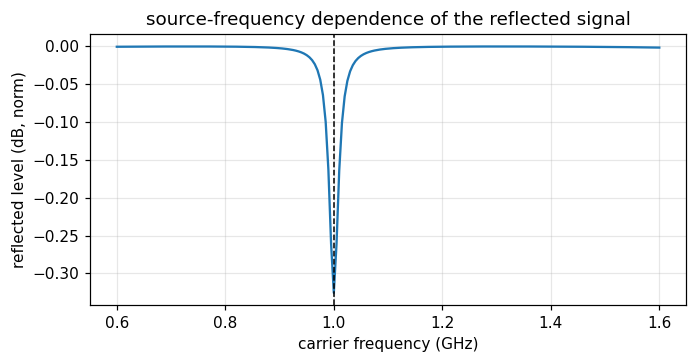

In [5]:
# amplitude: set by value or by available power in dBm
for p_dbm in [-20, -10, 0]:
    C["src"].set_power_dbm(p_dbm)
    r = net.run()
    print(f"source {p_dbm:+3d} dBm -> |V| at match.in = "
          f"{np.abs(r.voltage(C['match'].port('in')).env[0]):.4g}")
C["src"].amplitude = 1.0

# frequency: sweep the carrier and watch the reflected amplitude at the amplifier
freqs = np.linspace(0.6e9, 1.6e9, 201)
_, refl = net.sweep_frequency(freqs, C["amp"].port("in"), quantity="a")
plt.figure(figsize=(7, 3.2))
plt.plot(freqs/1e9, 20*np.log10(np.abs(refl)/np.max(np.abs(refl))))
plt.axvline(f0/1e9, ls="--", c="k", lw=1)
plt.xlabel("carrier frequency (GHz)"); plt.ylabel("reflected level (dB, norm)")
plt.title("source-frequency dependence of the reflected signal"); plt.show()


## 5. Impedance matching and sensitivity (paper Box 1)

The MIM probe (~1 pF) is matched near 50 Ω with the paper's canonical **λ/4 resonant
match**: a shunt inductor resonates out the probe capacitance (turning the probe into a
real resistance `R_loss = Q/(ωC)`), and a quarter-wave transformer of impedance
`√(Z0·R_loss)` steps that down to 50 Ω. `resonant_match(f0, C_probe, Q)` designs it.

A key physical point: a **lossless** reactive probe reflects everything (`|Γ| = 1`) no
matter what lossless matching you add — matching only rotates the *phase* of Γ. A real
match relies on the finite Q of the resonator, giving a `|Γ|` dip at resonance where the
sensitivity `|dΓ/dY|` — and hence the MIM signal — is largest.

design: {'L': '2.53e-08', 'R_loss': '6.37e+03', 'Z_qw': '564', 'length': '0.0749', 'f0': '1e+09', 'Q': '40', 'L_scale': '1', 'Zqw_scale': '1'}


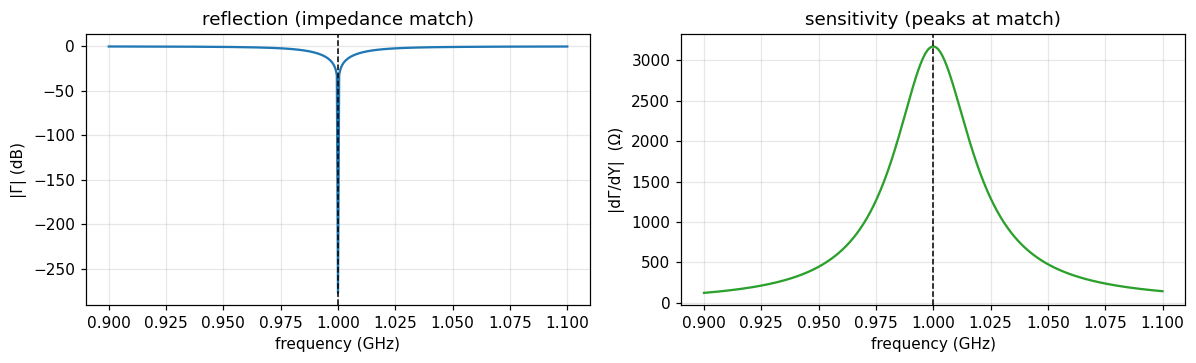

best match at 1.0000 GHz, |Γ| = -277.3 dB


In [6]:
match5 = resonant_match(f0, C_probe=1e-12, Q=40.0, name="match5")
print("design:", {k: f"{v:.3g}" for k, v in match5.design.items()})

# probe = 1 pF with finite Q (loss makes a real match possible)
w0 = 2*np.pi*f0
G_loss = w0*1e-12/40.0
probe = Load(Y=lambda f, t: 1j*2*np.pi*f*1e-12 + G_loss, name="probe")
mnet = Network(f0=f0); src2 = Source(f0, 1.0, name="src2")
mnet.connect(src2.port(0), match5.port("in"))
mnet.connect(match5.port("out"), probe.port(0))

freqs = np.linspace(0.9e9, 1.1e9, 401)
_, a = mnet.sweep_frequency(freqs, src2.port(0), "a")   # reflected at source
_, b = mnet.sweep_frequency(freqs, src2.port(0), "b")   # incident at source
gamma = a / b

# sensitivity |dGamma/dY|: perturb the probe conductance and re-solve
dG = 1e-6
probe2 = Load(Y=lambda f, t: 1j*2*np.pi*f*1e-12 + G_loss + dG, name="probe2")
m2 = resonant_match(f0, 1e-12, 40.0); mnet2 = Network(f0=f0); src3 = Source(f0, 1.0)
mnet2.connect(src3.port(0), m2.port("in")); mnet2.connect(m2.port("out"), probe2.port(0))
_, a2 = mnet2.sweep_frequency(freqs, src3.port(0), "a")
_, b2 = mnet2.sweep_frequency(freqs, src3.port(0), "b")
sens = np.abs((a2/b2 - gamma) / dG)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(freqs/1e9, 20*np.log10(np.abs(gamma)))
ax[0].axvline(f0/1e9, ls="--", c="k", lw=1)
ax[0].set(xlabel="frequency (GHz)", ylabel="|Γ| (dB)", title="reflection (impedance match)")
ax[1].plot(freqs/1e9, sens, color="C2")
ax[1].axvline(f0/1e9, ls="--", c="k", lw=1)
ax[1].set(xlabel="frequency (GHz)", ylabel="|dΓ/dY|  (Ω)", title="sensitivity (peaks at match)")
plt.tight_layout(); plt.show()
print("best match at %.4f GHz, |Γ| = %.1f dB"
      % (freqs[np.argmin(np.abs(gamma))]/1e9, 20*np.log10(np.abs(gamma).min())))


**Why it matters for MIM.** The matching network is not cosmetic: it sets how much
of the tiny tip-sample admittance change reaches the detector. Below we run the full
response-curve sweep **with and without** the match and compare the demodulated MIM
contrast — matching boosts it by roughly two orders of magnitude.

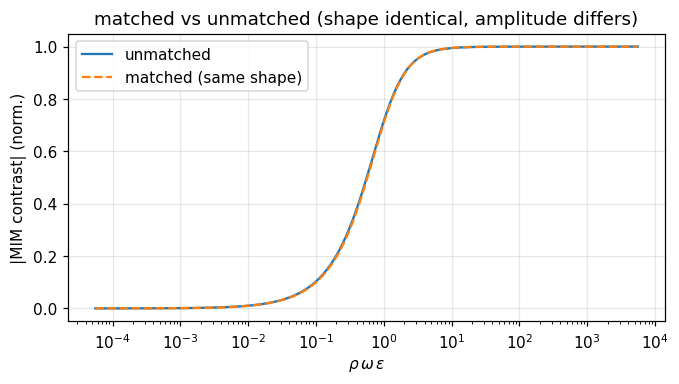

peak MIM contrast:  unmatched = 1.18e-07,  matched = 1.7e-05
matching improves the MIM signal by x144


In [7]:
def sweep_contrast(matched):
    src = Source(f0, 1.0, name="s"); cpl = DirectionalCoupler(10, 35, name="c")
    tipm = model.make_load(rho=lambda t: rho_grid[int(round(t))], eps_r=10.0, name="t")
    amp = Amplifier(30, name="a"); mix = IQMixer(name="m"); lo = PhaseShifter(0.0, name="lo")
    net = Network(f0=f0)
    net.connect(src.port(0), cpl.port("in"))
    if matched:
        mn = resonant_match(f0, 1e-12, 40.0)
        net.connect(cpl.port("through"), mn.port("in")); net.connect(mn.port("out"), tipm.port(0))
    else:
        net.connect(cpl.port("through"), tipm.port(0))
    net.connect(cpl.port("coupled"), lo.port("in")); net.connect(lo.port("out"), mix.port("lo"))
    net.connect(cpl.port("isolated"), amp.port("in")); net.connect(amp.port("out"), mix.port("rf"))
    d = mix.demodulate(net.run(t_grid=np.arange(rho_grid.size))).complex
    return np.abs(d - d[0])

rho_grid = np.logspace(-4, 4, 161)
c_un, c_ma = sweep_contrast(False), sweep_contrast(True)
xg = rho_grid * 2*np.pi*f0 * 10*EPS0
plt.figure(figsize=(7, 3.4))
plt.semilogx(xg, c_un/c_un.max(), label="unmatched")
plt.semilogx(xg, c_ma/c_ma.max(), "--", label="matched (same shape)")
plt.xlabel(r"$\rho\,\omega\,\varepsilon$"); plt.ylabel("|MIM contrast| (norm.)")
plt.legend(); plt.title("matched vs unmatched (shape identical, amplitude differs)")
plt.show()
print(f"peak MIM contrast:  unmatched = {c_un.max():.3g},  matched = {c_ma.max():.3g}")
print(f"matching improves the MIM signal by x{c_ma.max()/c_un.max():.0f}")


### 5b. Imperfect match — realistic mismatch and graceful sensitivity

A numerically ideal match gives `|Γ| → 0`, but real matches sit at `-20…-40 dB` from
component tolerances and thermal drift. `resonant_match` models this two ways: `mismatch_db`
leaves a residual mismatch *at* `f0` (left panel), and `L_scale` detunes the resonator so
the dip drifts *in frequency*. As the paper's Box 1 stresses, **a perfect match is not
required** — a modest residual mismatch barely costs signal. What does hurt is the resonator
drifting off `f0` (right panel): the MIM signal falls steadily with detuning, which is why
drift stabilization and low-frequency modulation matter in practice.

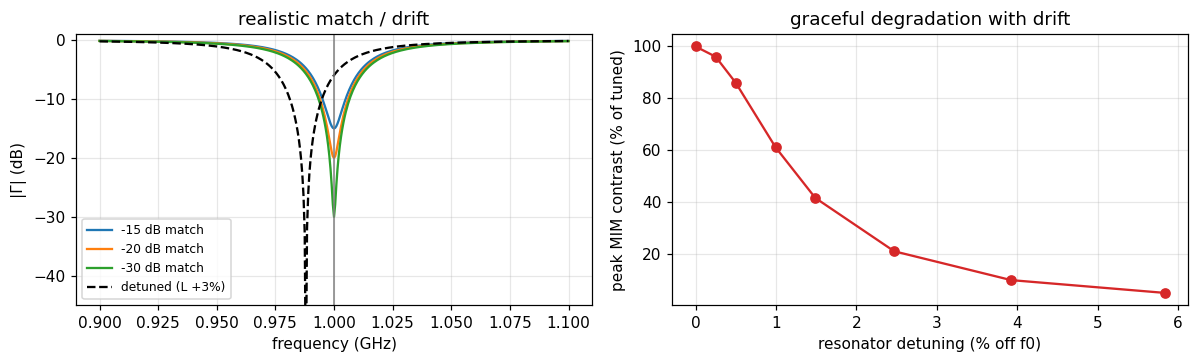

a 1% resonator drift retains 61% of the tuned MIM signal


In [8]:
# left: realistic |Γ| dips (residual mismatch) and a detuned (drifted) resonator
freqs = np.linspace(0.9e9, 1.1e9, 401)
def gamma_vs_f(**kw):
    mn = resonant_match(f0, 1e-12, 40.0, **kw)
    n = Network(f0=f0); s = Source(f0, 1.0)
    pr = Load(Y=lambda f, t: 1j*2*np.pi*f*1e-12 + 2*np.pi*f0*1e-12/40.0)
    n.connect(s.port(0), mn.port("in")); n.connect(mn.port("out"), pr.port(0))
    _, a = n.sweep_frequency(freqs, s.port(0), "a")
    _, b = n.sweep_frequency(freqs, s.port(0), "b")
    return a / b

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for mdb in [-15, -20, -30]:
    ax[0].plot(freqs/1e9, 20*np.log10(np.abs(gamma_vs_f(mismatch_db=mdb))), label=f"{mdb} dB match")
ax[0].plot(freqs/1e9, 20*np.log10(np.abs(gamma_vs_f(L_scale=1.03))), "k--", label="detuned (L +3%)")
ax[0].axvline(f0/1e9, c="gray", lw=1); ax[0].set_ylim(-45, 1)
ax[0].set(xlabel="frequency (GHz)", ylabel="|Γ| (dB)", title="realistic match / drift")
ax[0].legend(fontsize=8)

# right: peak MIM contrast as the resonator detunes off f0 (thermal drift)
def peak_contrast(match_kw):
    src = Source(f0, 1.0, name="s"); cpl = DirectionalCoupler(10, 35, name="c")
    tipm = model.make_load(rho=lambda t: rho_grid[int(round(t))], eps_r=10.0, name="t")
    amp = Amplifier(30, name="a"); mix = IQMixer(name="m"); lo = PhaseShifter(0.0, name="lo")
    mn = resonant_match(f0, 1e-12, 40.0, **match_kw)
    net = Network(f0=f0)
    net.connect(src.port(0), cpl.port("in"))
    net.connect(cpl.port("through"), mn.port("in")); net.connect(mn.port("out"), tipm.port(0))
    net.connect(cpl.port("coupled"), lo.port("in")); net.connect(lo.port("out"), mix.port("lo"))
    net.connect(cpl.port("isolated"), amp.port("in")); net.connect(amp.port("out"), mix.port("rf"))
    d = mix.demodulate(net.run(t_grid=np.arange(rho_grid.size))).complex
    return np.abs(d - d[0]).max()

L_scales = np.array([1.0, 1.005, 1.01, 1.02, 1.03, 1.05, 1.08, 1.12])
detune_pct = (np.sqrt(L_scales) - 1) * 100            # resonant-frequency shift (%)
contrast = np.array([peak_contrast(dict(L_scale=ls)) for ls in L_scales])
ax[1].plot(detune_pct, contrast/contrast[0]*100, "o-", color="C3")
ax[1].set(xlabel="resonator detuning (% off f0)", ylabel="peak MIM contrast (% of tuned)",
          title="graceful degradation with drift")
plt.tight_layout(); plt.show()
print(f"a 1% resonator drift retains "
      f"{np.interp(1.0, detune_pct, contrast/contrast[0]*100):.0f}% of the tuned MIM signal")


## 6. The MIM response curve (paper Fig. 1b)

Sweep the sample resistivity ρ and read the demodulated **MIM-Re** (dissipative) and
**MIM-Im** (reactive) channels. We encode the sweep on the slow-time axis, demodulate,
then **calibrate the LO phase** so that the dissipative response lands in MIM-Re — this
is exactly the phase adjustment done on a real instrument.

The dissipative channel peaks at `ρ·ω·ε ≈ 1` (σ ≈ ωε) and the reactive channel rises
monotonically toward the conductive side — the canonical MIM contrast window.

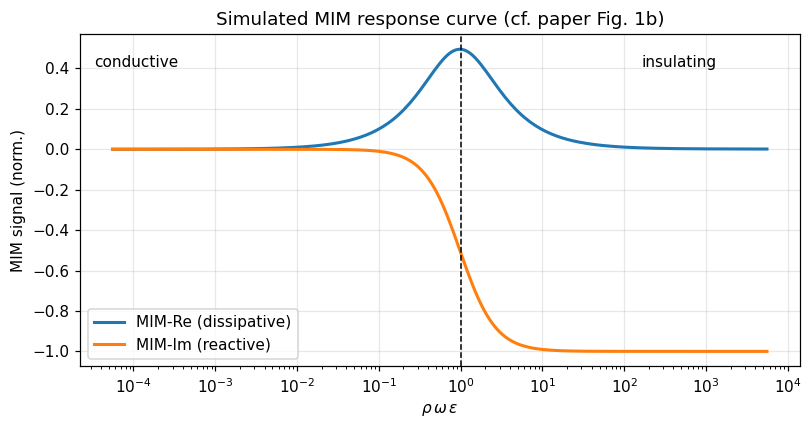

LO phase used for channel separation: 0.1 deg
MIM-Re peak at rho*w*eps = 0.952


In [9]:
rho_vals = np.logspace(-4, 4, 241)   # Ohm*m
w, eps = 2*np.pi*f0, 10*EPS0
x = rho_vals * w * eps               # dimensionless rho*omega*eps

tipR = model.make_load(rho=lambda t: rho_vals[int(round(t))], eps_r=10.0, name="tipR")
netR, CR = build_chain(f0, tipR)
resR = netR.run(t_grid=np.arange(rho_vals.size))
demod = CR["mix"].demodulate(resR)

# calibrate LO phase: null vs the conductive end, align to modelled delta-Y
Yts = np.array([model.Y_tipsample(f0, r, 10.0) for r in rho_vals])
dd = demod.complex - demod.complex[0]
aligned, phi = DemodResult(resR.t, dd).align_to(Yts - Yts[0])
mim_re = aligned.re / np.abs(aligned.complex).max()
mim_im = aligned.im / np.abs(aligned.complex).max()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogx(x, mim_re, label="MIM-Re (dissipative)", lw=2)
ax.semilogx(x, mim_im, label="MIM-Im (reactive)", lw=2)
ax.axvline(1.0, ls="--", c="k", lw=1)
ax.set_xlabel(r"$\rho\,\omega\,\varepsilon$"); ax.set_ylabel("MIM signal (norm.)")
ax.text(0.02, 0.9, "conductive", transform=ax.transAxes)
ax.text(0.78, 0.9, "insulating", transform=ax.transAxes)
ax.legend(); ax.set_title("Simulated MIM response curve (cf. paper Fig. 1b)")
plt.tight_layout(); plt.show()
print(f"LO phase used for channel separation: {np.degrees(phi):.1f} deg")
print(f"MIM-Re peak at rho*w*eps = {x[np.argmax(np.abs(mim_re))]:.3g}")


## 7. Distance modulation → the dMIM/dz signal

Oscillating the tip-sample gap `z(t)` modulates the tip-sample admittance. The raw
reflected carrier barely moves (aF on ~pF), but after the IQ mixer the tip oscillation is
a clean line at `f_mod` in the baseband — this is the lock-in `dMIM/dz` measurement, which
rejects slow drift.

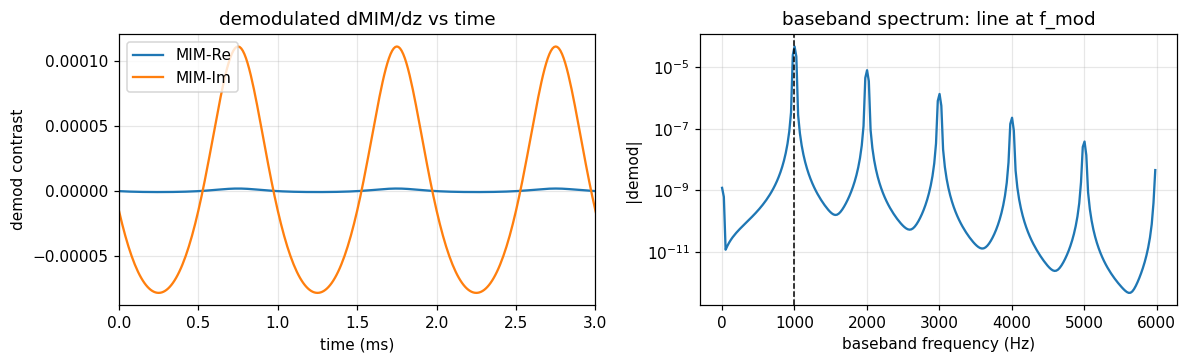

In [10]:
fmod, fs = 1e3, 100e3
tmod = np.arange(4096) / fs
zmod = lambda tt: 5e-9 * (1 + np.sin(2*np.pi*fmod*tt))   # 0..10 nm gap
tipZ = model.make_load(rho=1.0, eps_r=10.0, z=zmod, name="tipZ")
netZ, CZ = build_chain(f0, tipZ)
resZ = netZ.run(t_grid=tmod)
dmz = CZ["mix"].demodulate(resZ)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(tmod*1e3, dmz.re - dmz.re.mean(), label="MIM-Re")
ax[0].plot(tmod*1e3, dmz.im - dmz.im.mean(), label="MIM-Im")
ax[0].set(xlabel="time (ms)", ylabel="demod contrast", title="demodulated dMIM/dz vs time")
ax[0].set_xlim(0, 3); ax[0].legend()

sig = Signal(dmz.complex - dmz.complex.mean(), f0=0.0, t=tmod)
fb, S = sig.baseband_spectrum()
keep = (fb >= 0) & (fb < 6*fmod)
ax[1].semilogy(fb[keep], np.abs(S)[keep])
ax[1].axvline(fmod, ls="--", c="k", lw=1)
ax[1].set(xlabel="baseband frequency (Hz)", ylabel="|demod|",
          title="baseband spectrum: line at f_mod")
plt.tight_layout(); plt.show()


## 8. Carrier cancellation — tuning the cancellation arm

The cancellation arm built into the chain (Section 1) injects a wave that **meets the
reflected wave at the combiner** and nulls the carrier before the amplifier, allowing
higher gain without saturation (paper, Fig. 1a). Here we tune its attenuation `A` and
phase `ϕ` to minimize the carrier at the amplifier input — a coarse grid to seed, then a
local refine (the null is narrow in phase).

carrier at amplifier input:  cancellation off = 0.1468
                             cancellation on  = 5.94e-14
null = -247.9 dB  (A = 7.6 dB, phi = 180 deg)


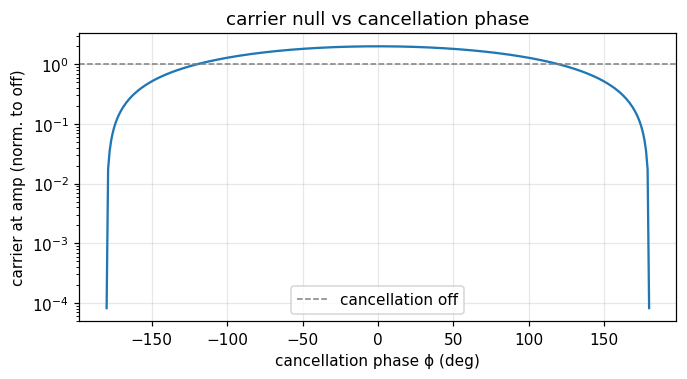

In [11]:
from scipy.optimize import minimize

# the cancellation arm already lives in the main chain: C["can_att"], C["can_ph"]
C["can_att"].response = lambda v: v          # interpret control voltage as attenuation (dB)
C["can_att"].voltage = 120.0                 # off -> bare reflected carrier
carrier0 = np.abs(net.run().incident(C["amp"].port("in")).env[0])

def carrier_at(p):
    aB, ph = p
    C["can_att"].voltage = max(aB, 0.0)
    C["can_ph"].voltage = ph
    return np.abs(net.run().incident(C["amp"].port("in")).env[0])

# coarse grid seed, then Nelder-Mead refine
seed = min(((a, ph) for a in np.linspace(0, 25, 26)
            for ph in np.linspace(-np.pi, np.pi, 49)), key=carrier_at)
opt = minimize(carrier_at, list(seed), method="Nelder-Mead",
               options={"xatol": 1e-4, "fatol": 1e-13})
carrier1 = carrier_at(opt.x)
print(f"carrier at amplifier input:  cancellation off = {carrier0:.4g}")
print(f"                             cancellation on  = {carrier1:.3g}")
print(f"null = {20*np.log10(carrier1/carrier0):.1f} dB  "
      f"(A = {opt.x[0]:.1f} dB, phi = {np.degrees(opt.x[1]):.0f} deg)")

# carrier vs cancellation phase at the tuned attenuation -> the null
C["can_att"].voltage = opt.x[0]
phs = np.linspace(-np.pi, np.pi, 361)
curve = np.empty_like(phs)
for i, ph in enumerate(phs):
    C["can_ph"].voltage = ph
    curve[i] = np.abs(net.run().incident(C["amp"].port("in")).env[0])
plt.figure(figsize=(7, 3.4))
plt.semilogy(np.degrees(phs), curve / carrier0)
plt.axhline(1.0, ls="--", c="gray", lw=1, label="cancellation off")
plt.xlabel("cancellation phase ϕ (deg)"); plt.ylabel("carrier at amp (norm. to off)")
plt.title("carrier null vs cancellation phase"); plt.legend(); plt.show()
C["can_att"].voltage = 120.0; C["can_ph"].voltage = 0.0     # reset (off)


## Summary

`mimsim` gives you a physically-grounded, fully-probeable MIM electronics model:

| requirement | how |
|---|---|
| probe signal at any component in/out | `res.incident/reflected/voltage/current(port)` |
| time domain **and** frequency domain | `Signal.waveform()` / `Signal.spectrum()` |
| voltage-controlled attenuator / phase | `Attenuator(voltage=…, response=…)`, `PhaseShifter(…)` |
| tunable source amplitude / frequency | `Source.amplitude`, `Source.set_power_dbm`, `Source.f0` |
| reflections / matching / cancellation | full `(I − S·P)·b = b_src` scattering solve |
| tip-sample physics | `TipSampleModel` → response curve, dMIM/dz |

Extend it by subclassing `Component` (implement `s_matrix(f, t)`), or add slow-time
modulation by passing any parameter as a callable of `t`.